# CNV Inference Across Smoothing Neighbor Counts

This notebook compares multiple smoothing neighbor counts while keeping the inferCNV window-size settings fixed.

Outputs are written under this directory:
- `data/`
- `figures/`
- `results/average_tumor_CNV_values_per_gene/`


In [1]:
import infercnvpy as cnv
import scanpy as sc
import pandas as pd
import numpy as np
import sys
import os

sys.path.append('/home/augusta/storage3/augusta/insituCNV/InSituCNV')
import insitucnv as icv

import matplotlib.pyplot as plt
import squidpy as sq
from matplotlib import cm
from matplotlib.colors import to_hex

sc.settings.verbosity = 3
plt.rcParams['figure.figsize'] = (16, 16)


/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data


In [3]:
sample_name = '1105_BL'
h5ad_path = "/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/data/1105_BL.h5ad"
adata = sc.read_h5ad(h5ad_path)
adata

AnnData object with n_obs × n_vars = 19413 × 5099
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'cell.id', 'cell_type_oct25', 'compartment'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'cell_type_oct25_colors', 'compartment_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'
    obsp: 'con

## Add Genomic Positions


In [4]:
adata = icv.pp.add_genomic_positions(adata)

Added genomic positions and ids to 5090 genes, out of 5099 genes in total!


## Settings


In [22]:
neighbors_list = [10, 20, 50, 1000]
window_size = 60
step = 10
reference_key = 'cell_type_oct25'
reference_cat = ["T_cells", "B_cells", "Myeloid", "Plasma","Fibroblast", "Endothelial", "Adipocytes", "PVLs"]
lfc_clip = 4
chunksize = 1000

base_dir = r'/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_n_neighbors'
fig_dir = os.path.join(base_dir, 'figures')
data_dir = os.path.join(base_dir, 'data')
tumor_csv_dir = os.path.join(base_dir, 'results', 'average_tumor_CNV_values_per_gene')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)
os.makedirs(tumor_csv_dir, exist_ok=True)

## Build Smoothed Layers for Each Neighbor Count and run inferCNV + clustering

Running insituCNV with 10 neighbors for smoothing
normalizing counts per cell
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
normalizing counts per cell
    finished (0:00:00)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:15<00:00,  3.78s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 21 clusters and added
    'cnv_leiden_n10', the cluster labels (adata.obs, categorical) (0:00:13)
computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_n10']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


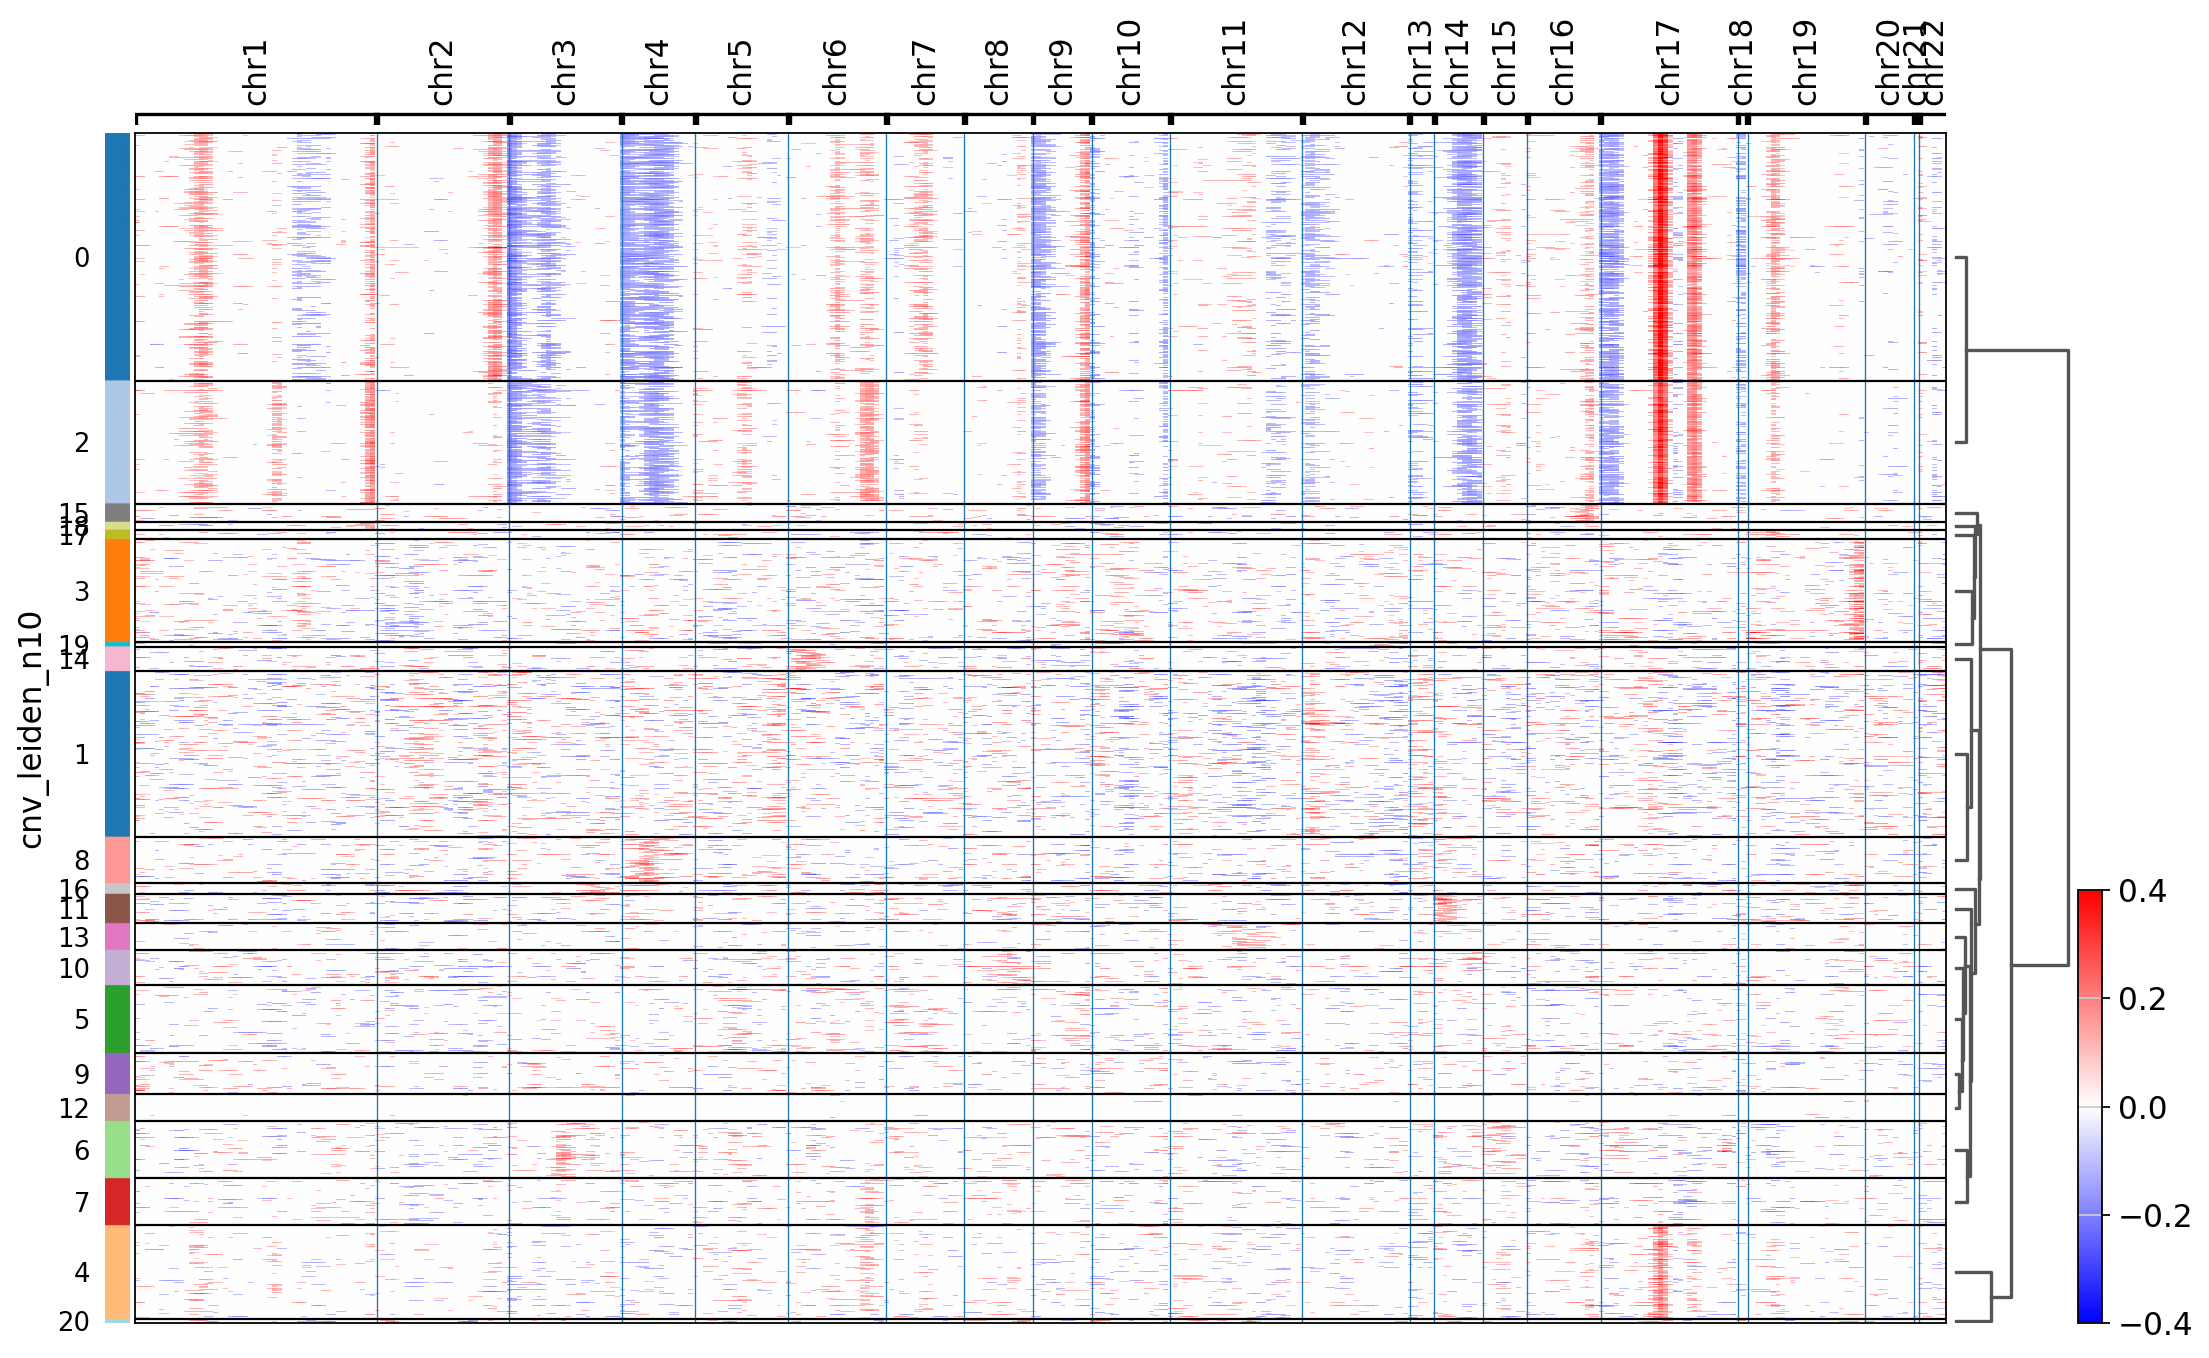

Running insituCNV with 20 neighbors for smoothing
normalizing counts per cell
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
normalizing counts per cell
    finished (0:00:00)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:17<00:00,  3.85s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 21 clusters and added
    'cnv_leiden_n20', the cluster labels (adata.obs, categorical) (0:00:12)
computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_n20']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


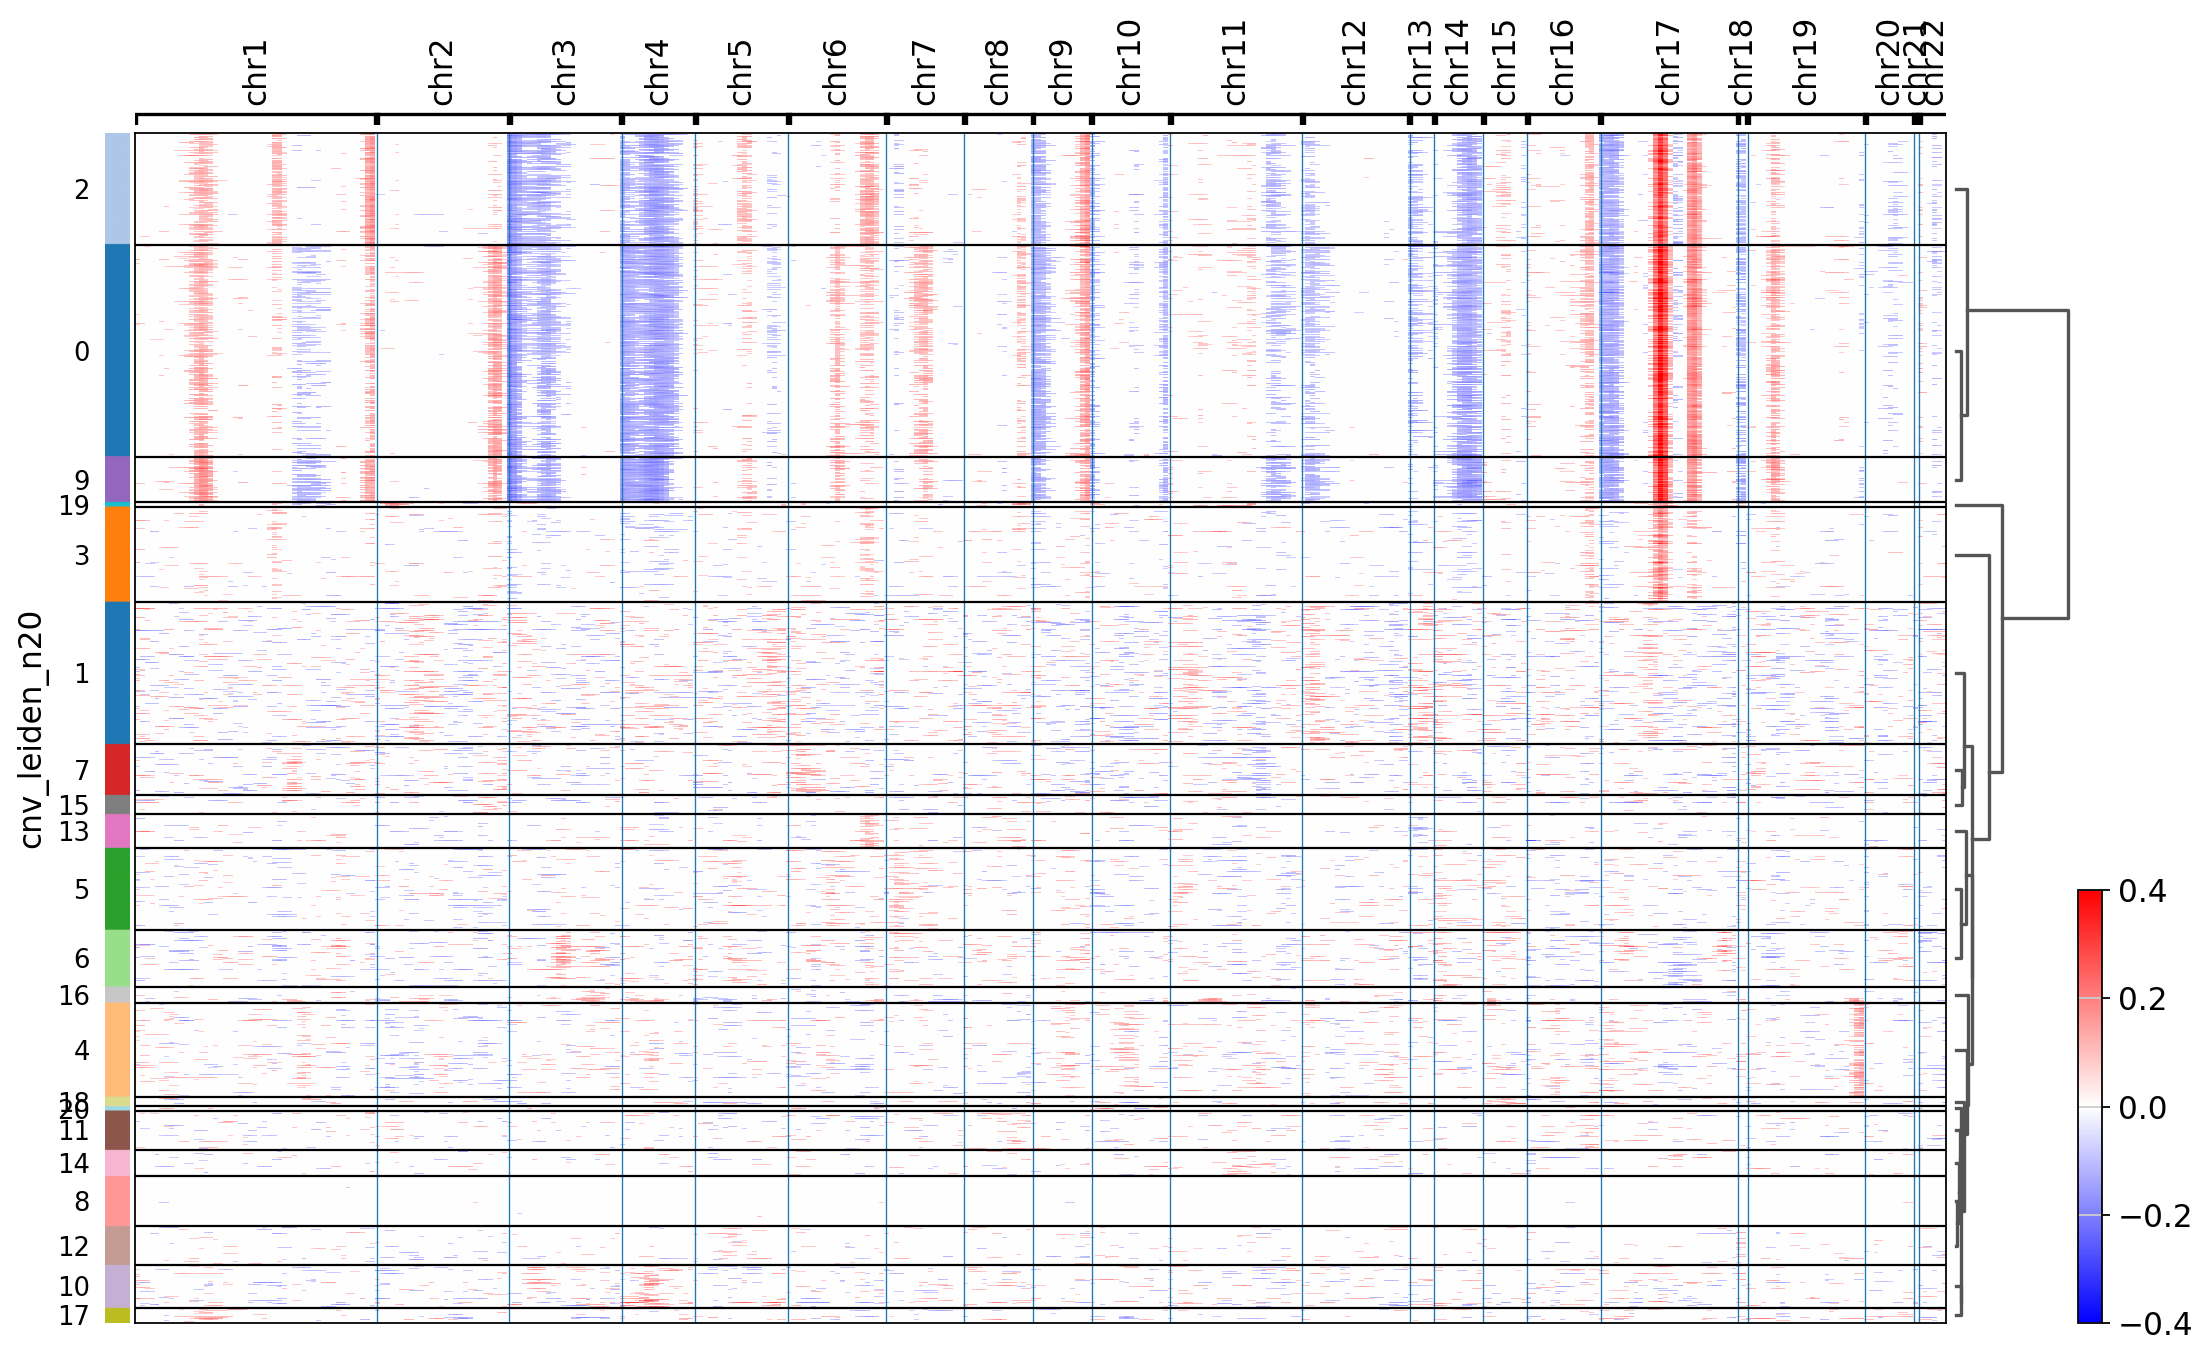

Running insituCNV with 50 neighbors for smoothing
normalizing counts per cell
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
normalizing counts per cell
    finished (0:00:00)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:17<00:00,  3.87s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 23 clusters and added
    'cnv_leiden_n50', the cluster labels (adata.obs, categorical) (0:00:09)
computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_n50']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


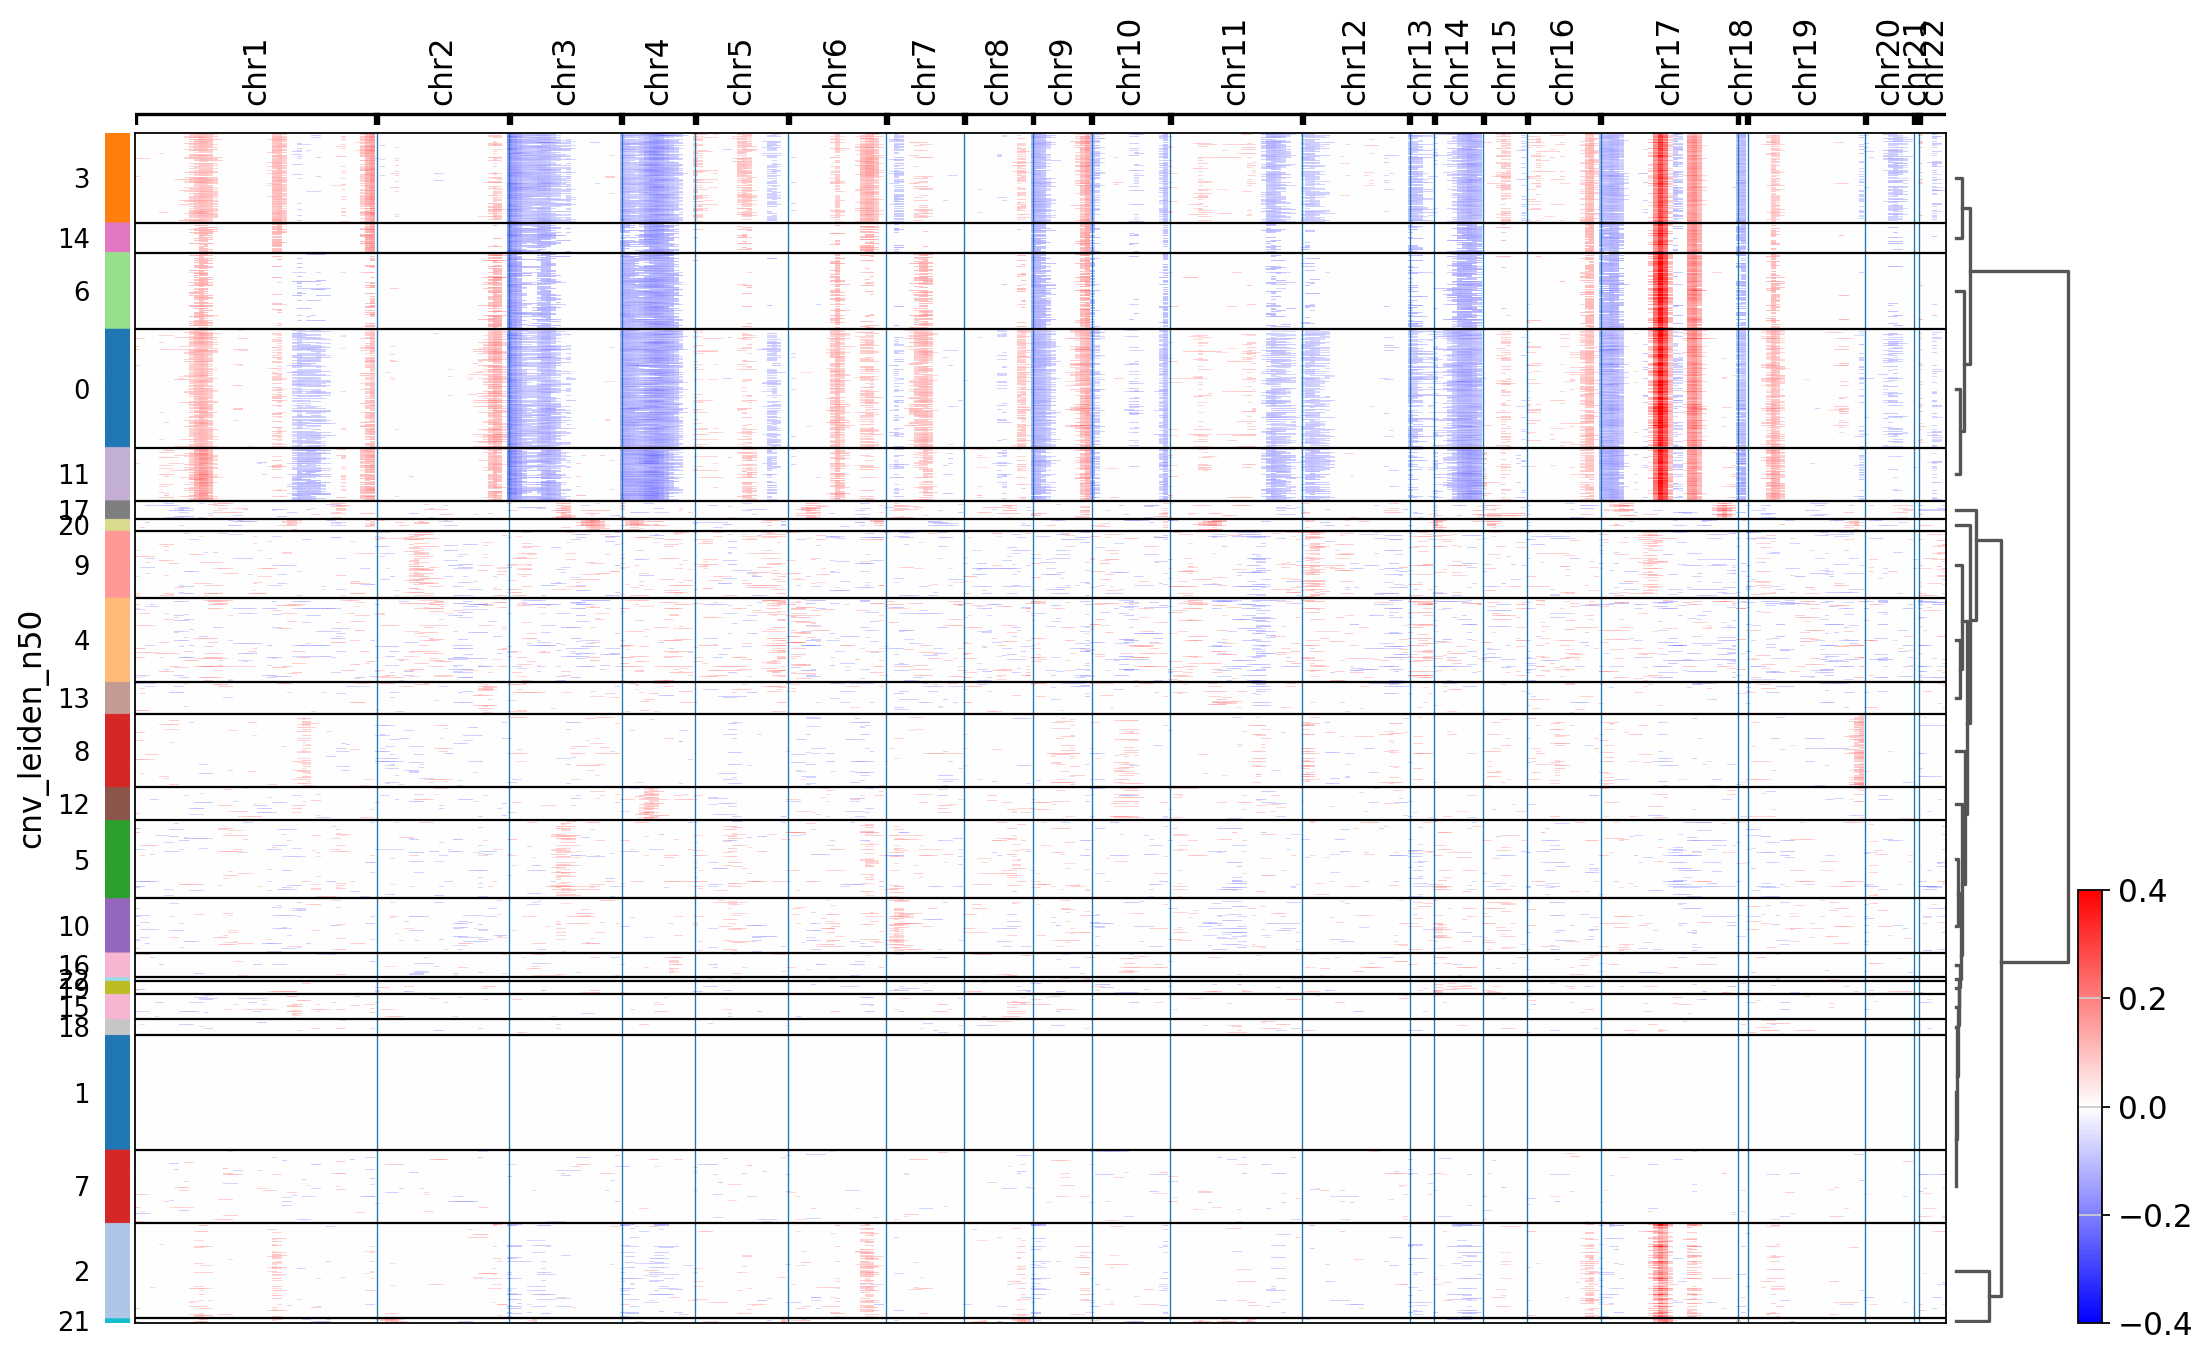

Running insituCNV with 1000 neighbors for smoothing
normalizing counts per cell
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:03:31)
normalizing counts per cell
    finished (0:00:00)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:08<00:00,  3.43s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:04)
running Leiden clustering
    finished: found 78 clusters and added
    'cnv_leiden_n1000', the cluster labels (adata.obs, categorical) (0:00:12)
computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_n1000']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


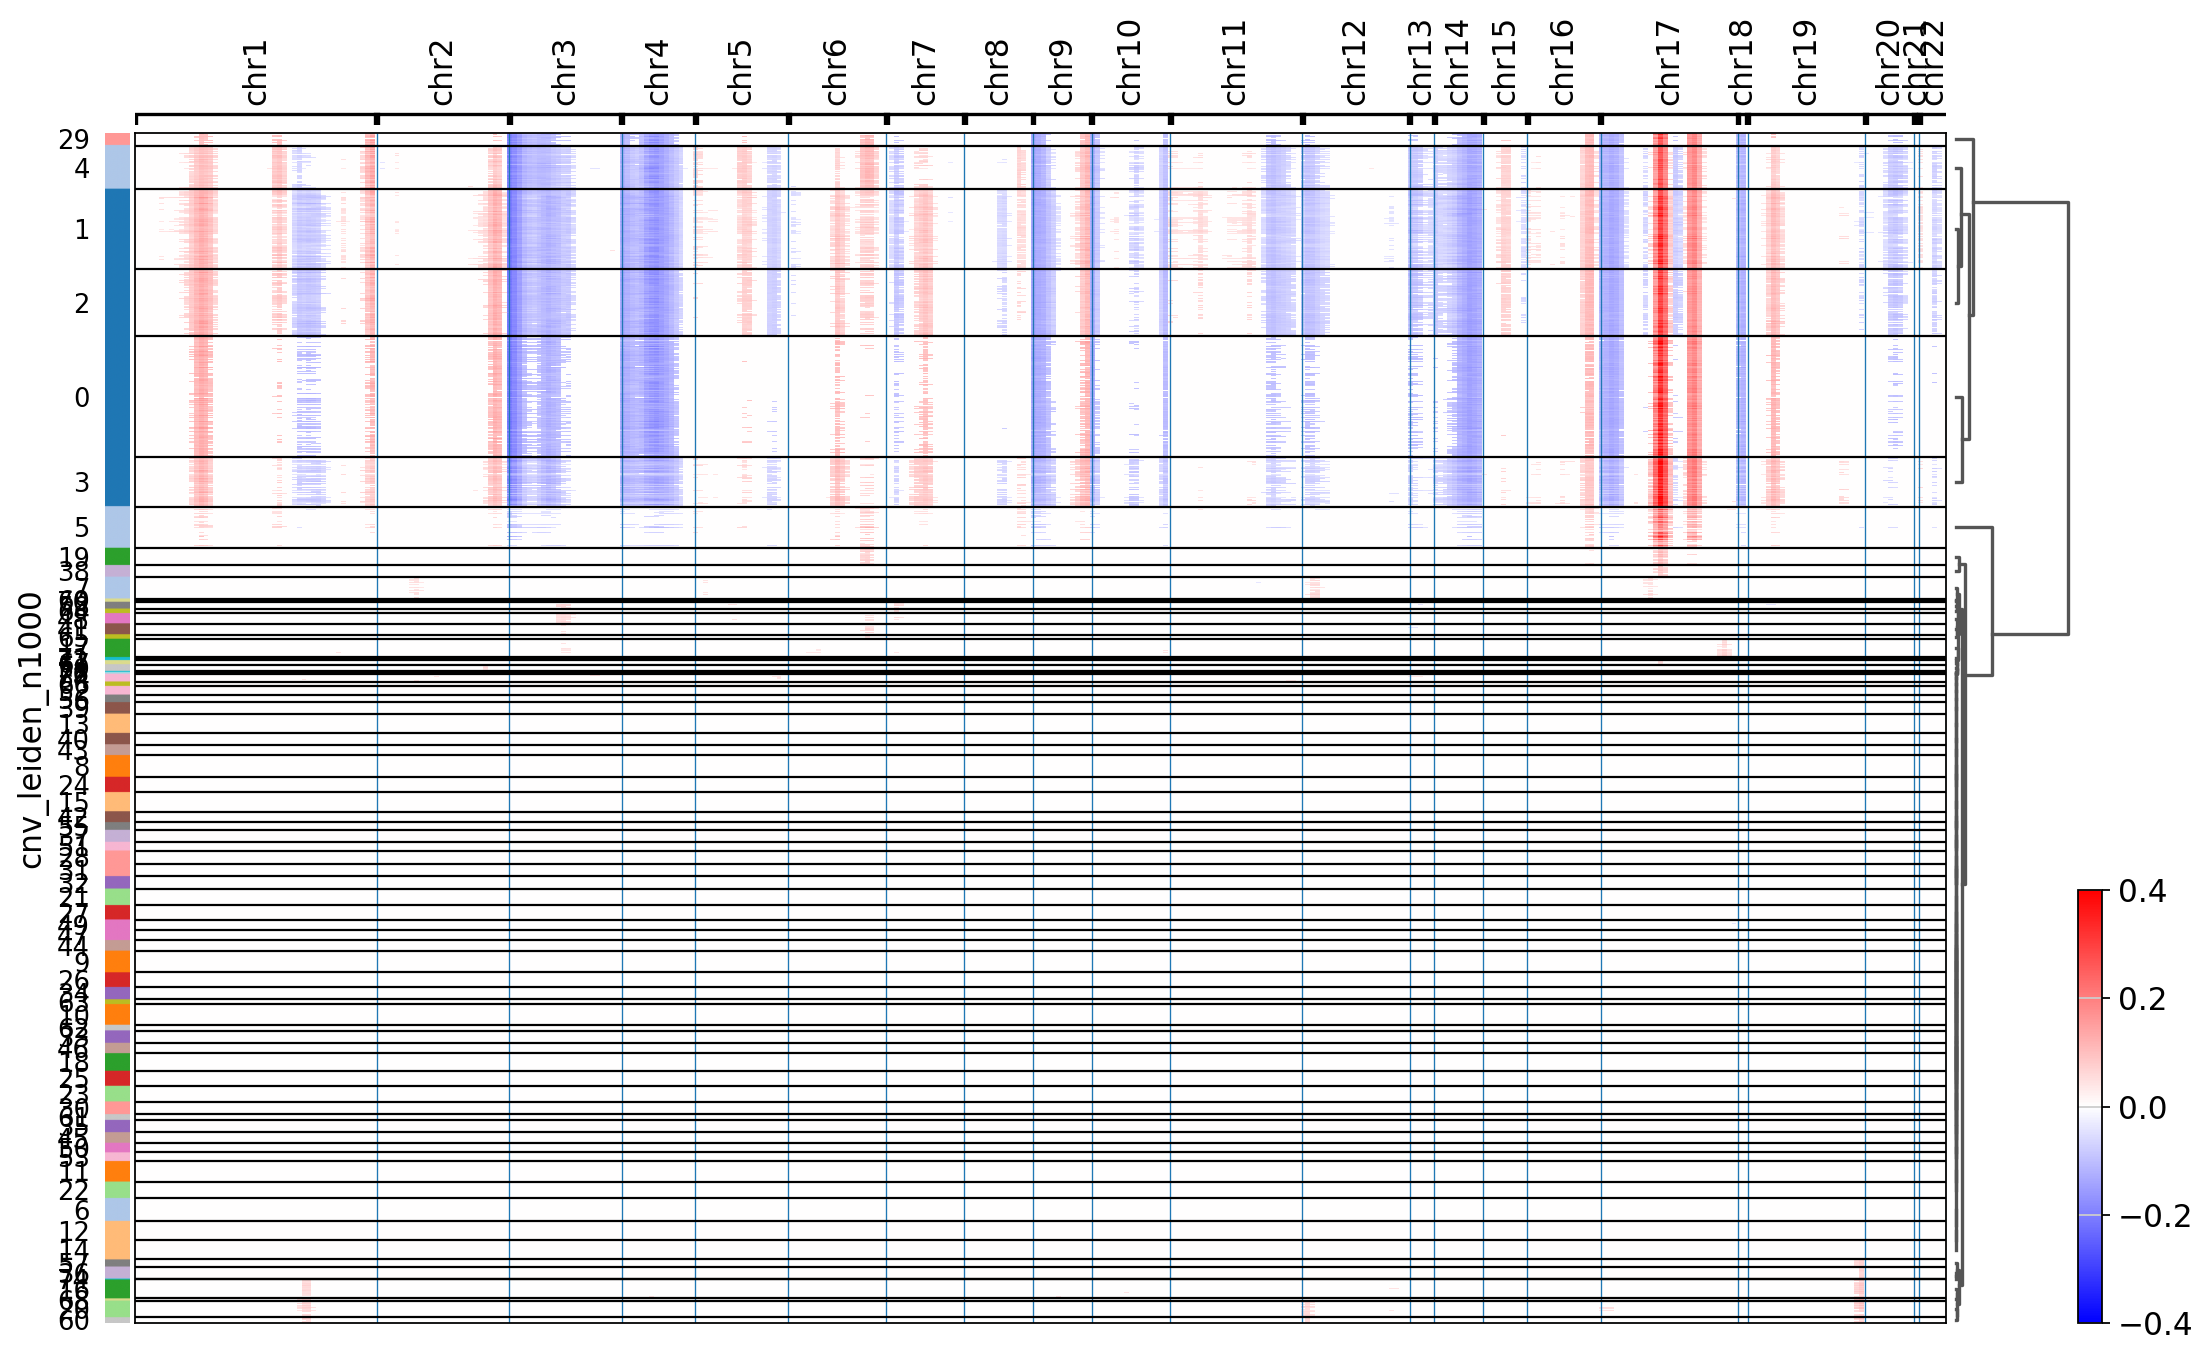

In [23]:
if 'raw_counts' not in adata.layers:
    adata.layers['raw_counts'] = adata.X.copy()


def run_insituCNV(ad, n_neighbors):

    """Construct one smoothing-based expression layer for a chosen neighbor count."""
    ad.X = ad.layers['raw_counts'].copy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    ad.layers[f'raw_n{n_neighbors}'] = ad.X.copy()
    sc.pp.neighbors(ad, n_neighbors=n_neighbors)
    icv.tl.smooth_data_for_cnv(ad, layer_w_norm_counts=f'raw_n{n_neighbors}', n_neighbors=n_neighbors)
    
    ad.layers[f'M_n{n_neighbors}'] = ad.layers['M'].copy()
    ad.X = ad.layers[f'M_n{n_neighbors}'].copy()
    
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)
    ad.layers[f'smooth_n{n_neighbors}'] = ad.X.copy()
    
    """InferCNV"""
    ad.X = ad.layers[f'smooth_n{n_neighbors}'].copy()
    label = f'n{n_neighbors}'
    cnv.tl.infercnv(
        ad,
        window_size=window_size,
        step=step,
        lfc_clip=lfc_clip,
        reference_key=reference_key,
        reference_cat=reference_cat,
        chunksize=chunksize,
        calculate_gene_values=True,
    )
    # Add layer w CNV values for the genes
    ad.layers[f'gene_values_cnv_{label}'] = ad.layers['gene_values_cnv'].copy()
    
    """Cluster"""
    cnv.tl.pca(ad)
    cnv.pp.neighbors(ad)

    leiden_key = f'cnv_leiden_{label}'
    cnv.tl.leiden(ad, key_added=leiden_key)

    color_key = f'{leiden_key}_colors'
    if color_key in ad.uns:
        del ad.uns[color_key]
    n = ad.obs[leiden_key].nunique()
    ad.uns[color_key] = [to_hex(cm.tab20(i / max(n, 1))) for i in range(n)]
    

    """Generate and save the heatmap"""
    cnv.pl.chromosome_heatmap(
        ad,
        dendrogram=True,
        groupby=f'cnv_leiden_{label}',
        vmax=0.4,
        vmin=-0.4,
        save=f'_cnv_leiden_{label}.pdf',
    )


for n in neighbors_list:
    print(f'Running insituCNV with {n} neighbors for smoothing')
    run_insituCNV(adata, n)


# restore original X
adata.X = adata.layers['raw_counts'].copy()

## Annotate Tumor CNV Clusters Per Neighbor Count

Fill in the tumor cluster IDs for each neighbor count before exporting tumor-average CNV tables.


In [25]:
tumor_clusters = {
    #'n5': {'0','1'},
    'n10':  {'0','2'},
    'n20':  {'2','0','9'},
    'n50':  {'6','14','3','0','11'},
    #'n200':  {'24','0','16','1','31','2','10'},
    'n1000':  {'29','4','1','2','0','3'},

}

for n in neighbors_list:
    label = f'n{n}'
    key = f'cnv_leiden_{label}'
    status_key = f'cnv_status_{label}'
    layer_name = f'gene_values_cnv_{label}'

    adata.obs[status_key] = adata.obs[key].astype(str).map(
        lambda x: 'tumor' if x in tumor_clusters.get(label, set()) else 'normal'
    )

    tumor_mask = adata.obs[status_key] == 'tumor'
    tumor_count = int(tumor_mask.sum())
    print(f'{label}: found {tumor_count} tumor cells')

    if tumor_count == 0:
        print(f'Skipping {label}: no tumor cells found')
        continue

    if layer_name not in adata.layers:
        print(f'Skipping {label}: layer {layer_name} not found')
        continue

    tumor_matrix = adata[tumor_mask].layers[layer_name]
    tumor_mean = tumor_matrix.mean(axis=0)

    if hasattr(tumor_mean, 'A1'):
        tumor_mean = tumor_mean.A1
    else:
        tumor_mean = np.asarray(tumor_mean).reshape(-1)

    out_df = adata.var.copy()
    if 'gene' not in out_df.columns:
        out_df['gene'] = adata.var_names

    out_df = out_df[['gene', 'chromosome', 'start', 'end']].copy()
    out_df['CNV_value'] = tumor_mean

    out_csv = os.path.join(tumor_csv_dir, f'{sample_name}_tumor_mean_smooth_neighbors{n}.csv')
    out_df.to_csv(out_csv, index=False)
    print(f'Saved tumor mean CNV table ({label}) -> {out_csv}')

n10: found 6052 tumor cells
Saved tumor mean CNV table (n10) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_n_neighbors/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_smooth_neighbors10.csv
n20: found 6029 tumor cells
Saved tumor mean CNV table (n20) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_n_neighbors/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_smooth_neighbors20.csv
n50: found 6004 tumor cells
Saved tumor mean CNV table (n50) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_n_neighbors/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_smooth_neighbors50.csv
n1000: found 6098 tumor cells
Saved tumor mean CNV table (n1000) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_n_neighbors/results/average_tumo

## Spatial Plots by Neighbor Count


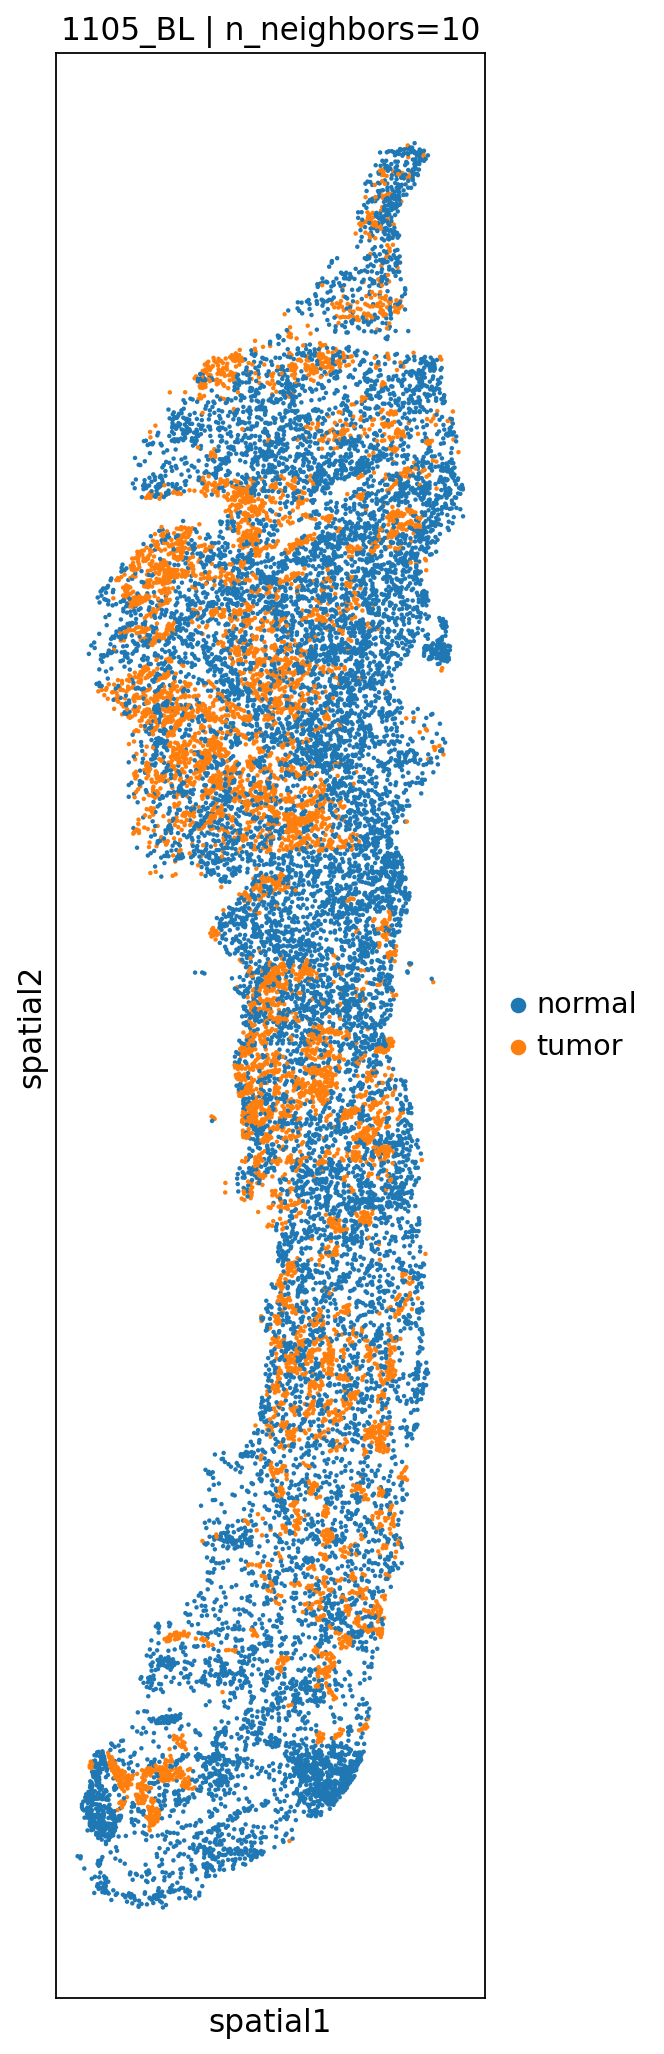

computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_status_n10']`
categories: normal, tumor
var_group_labels: chr1, chr2, chr3, etc.


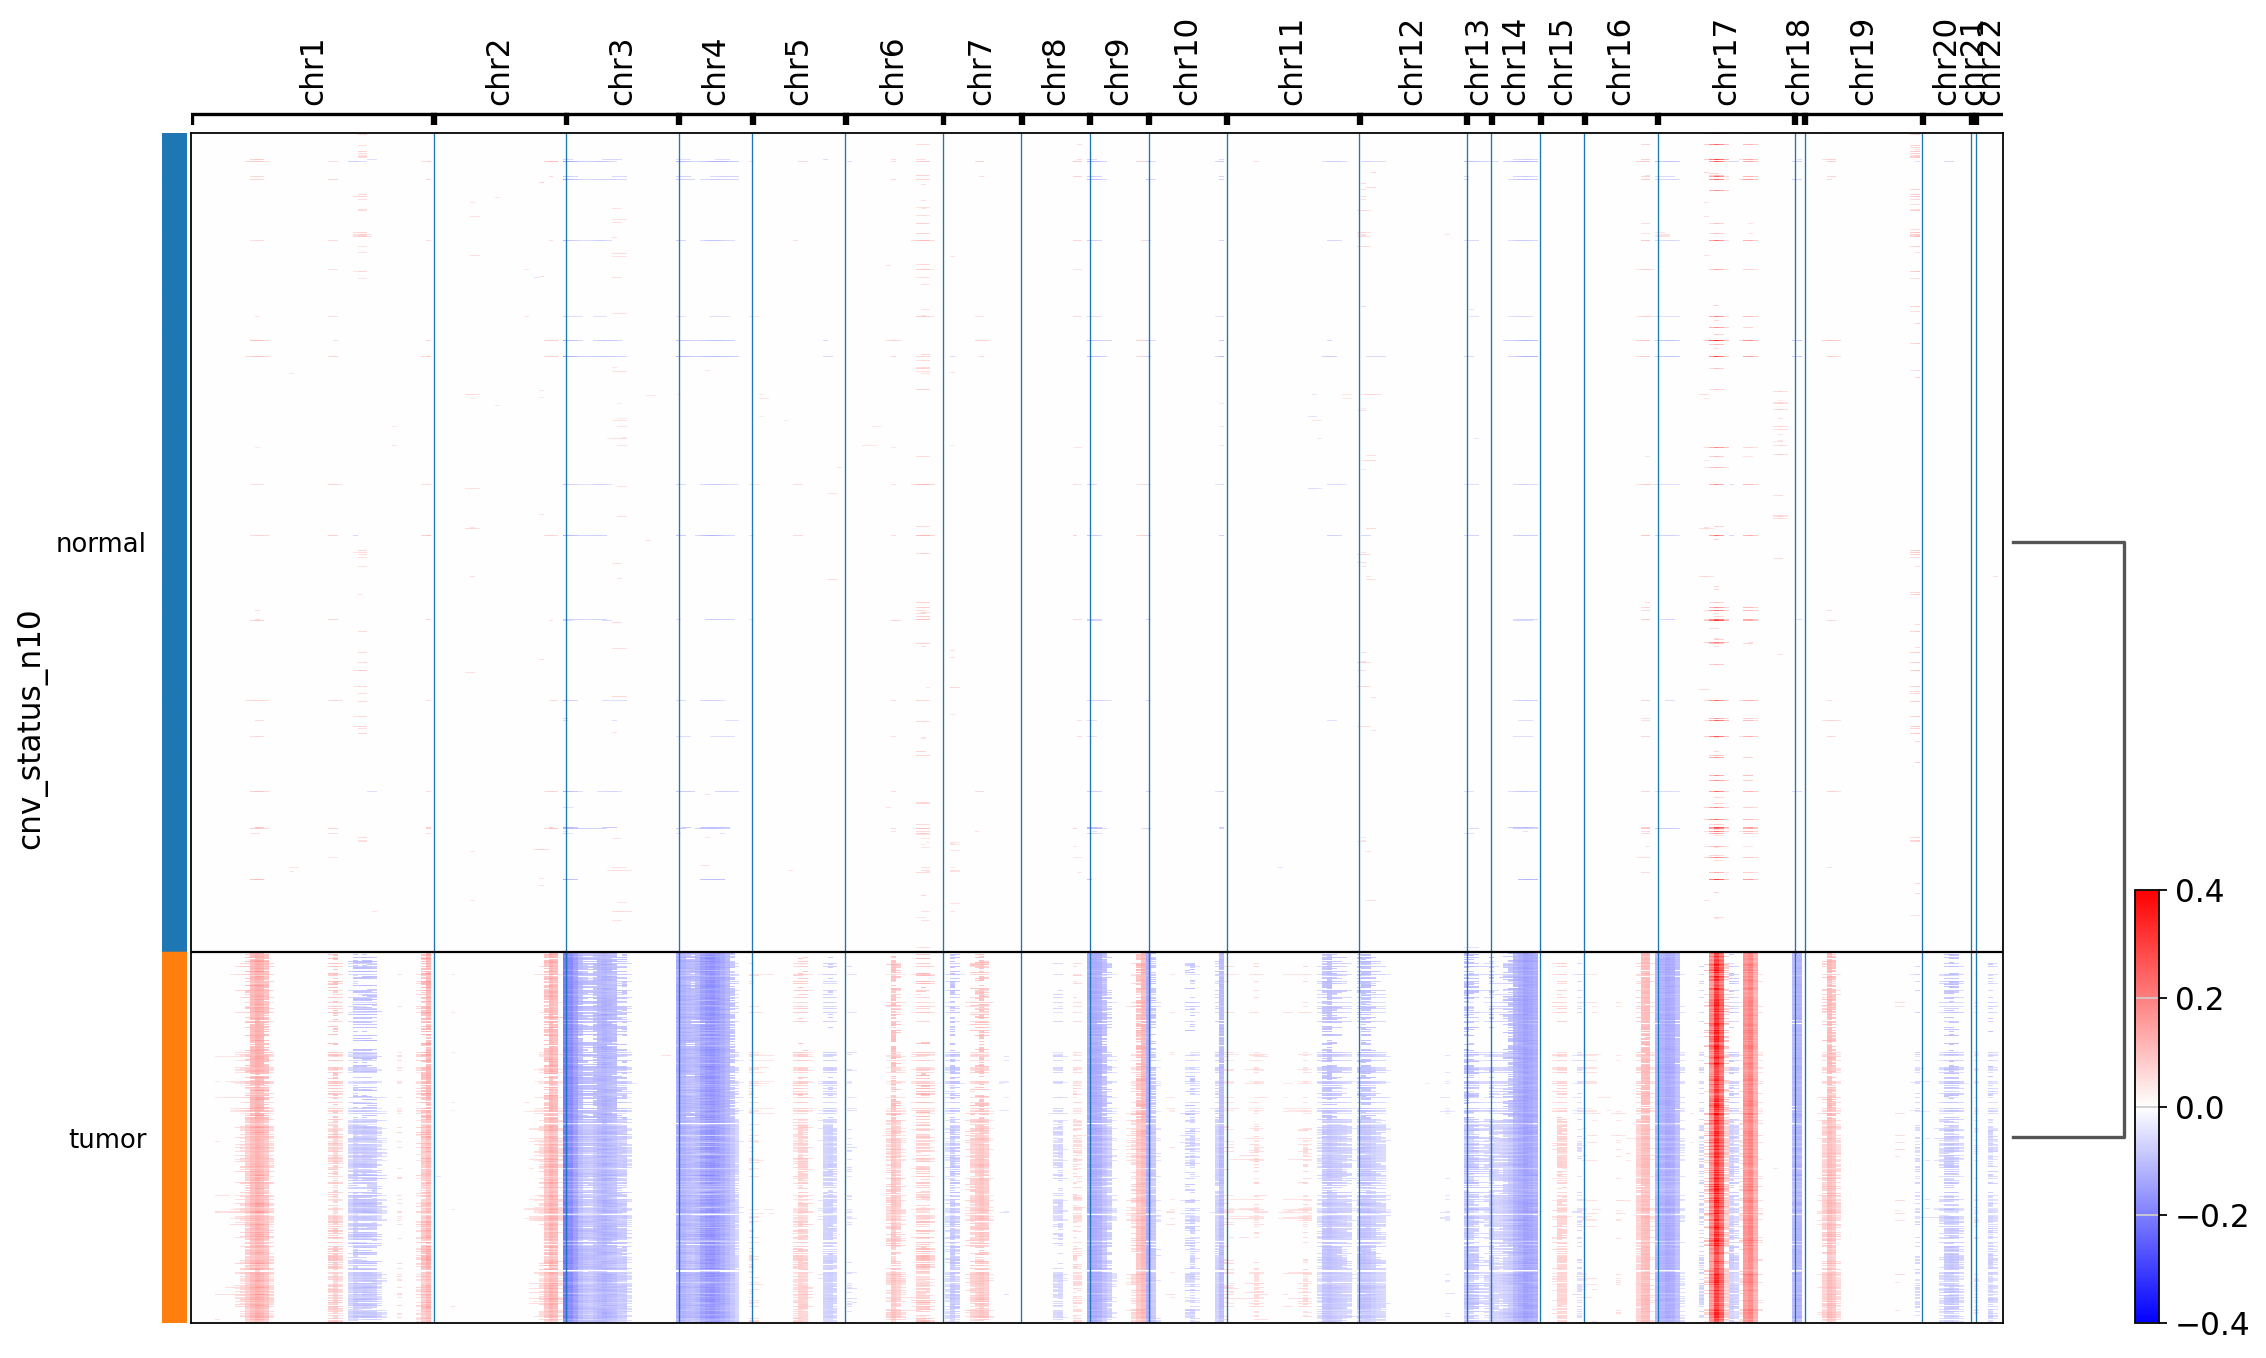

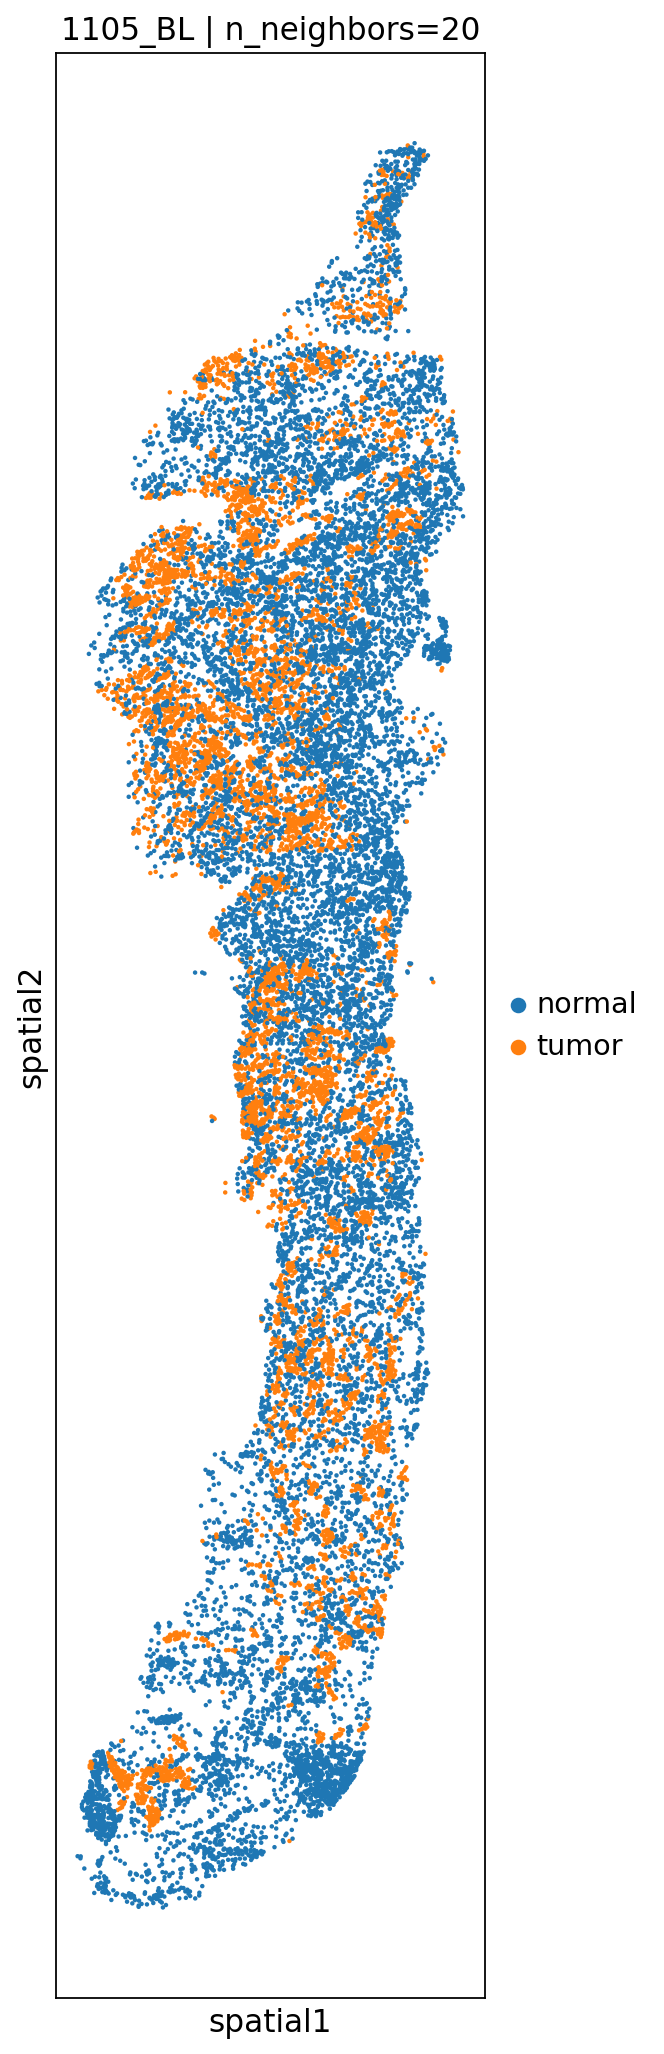

computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_status_n20']`
categories: normal, tumor
var_group_labels: chr1, chr2, chr3, etc.


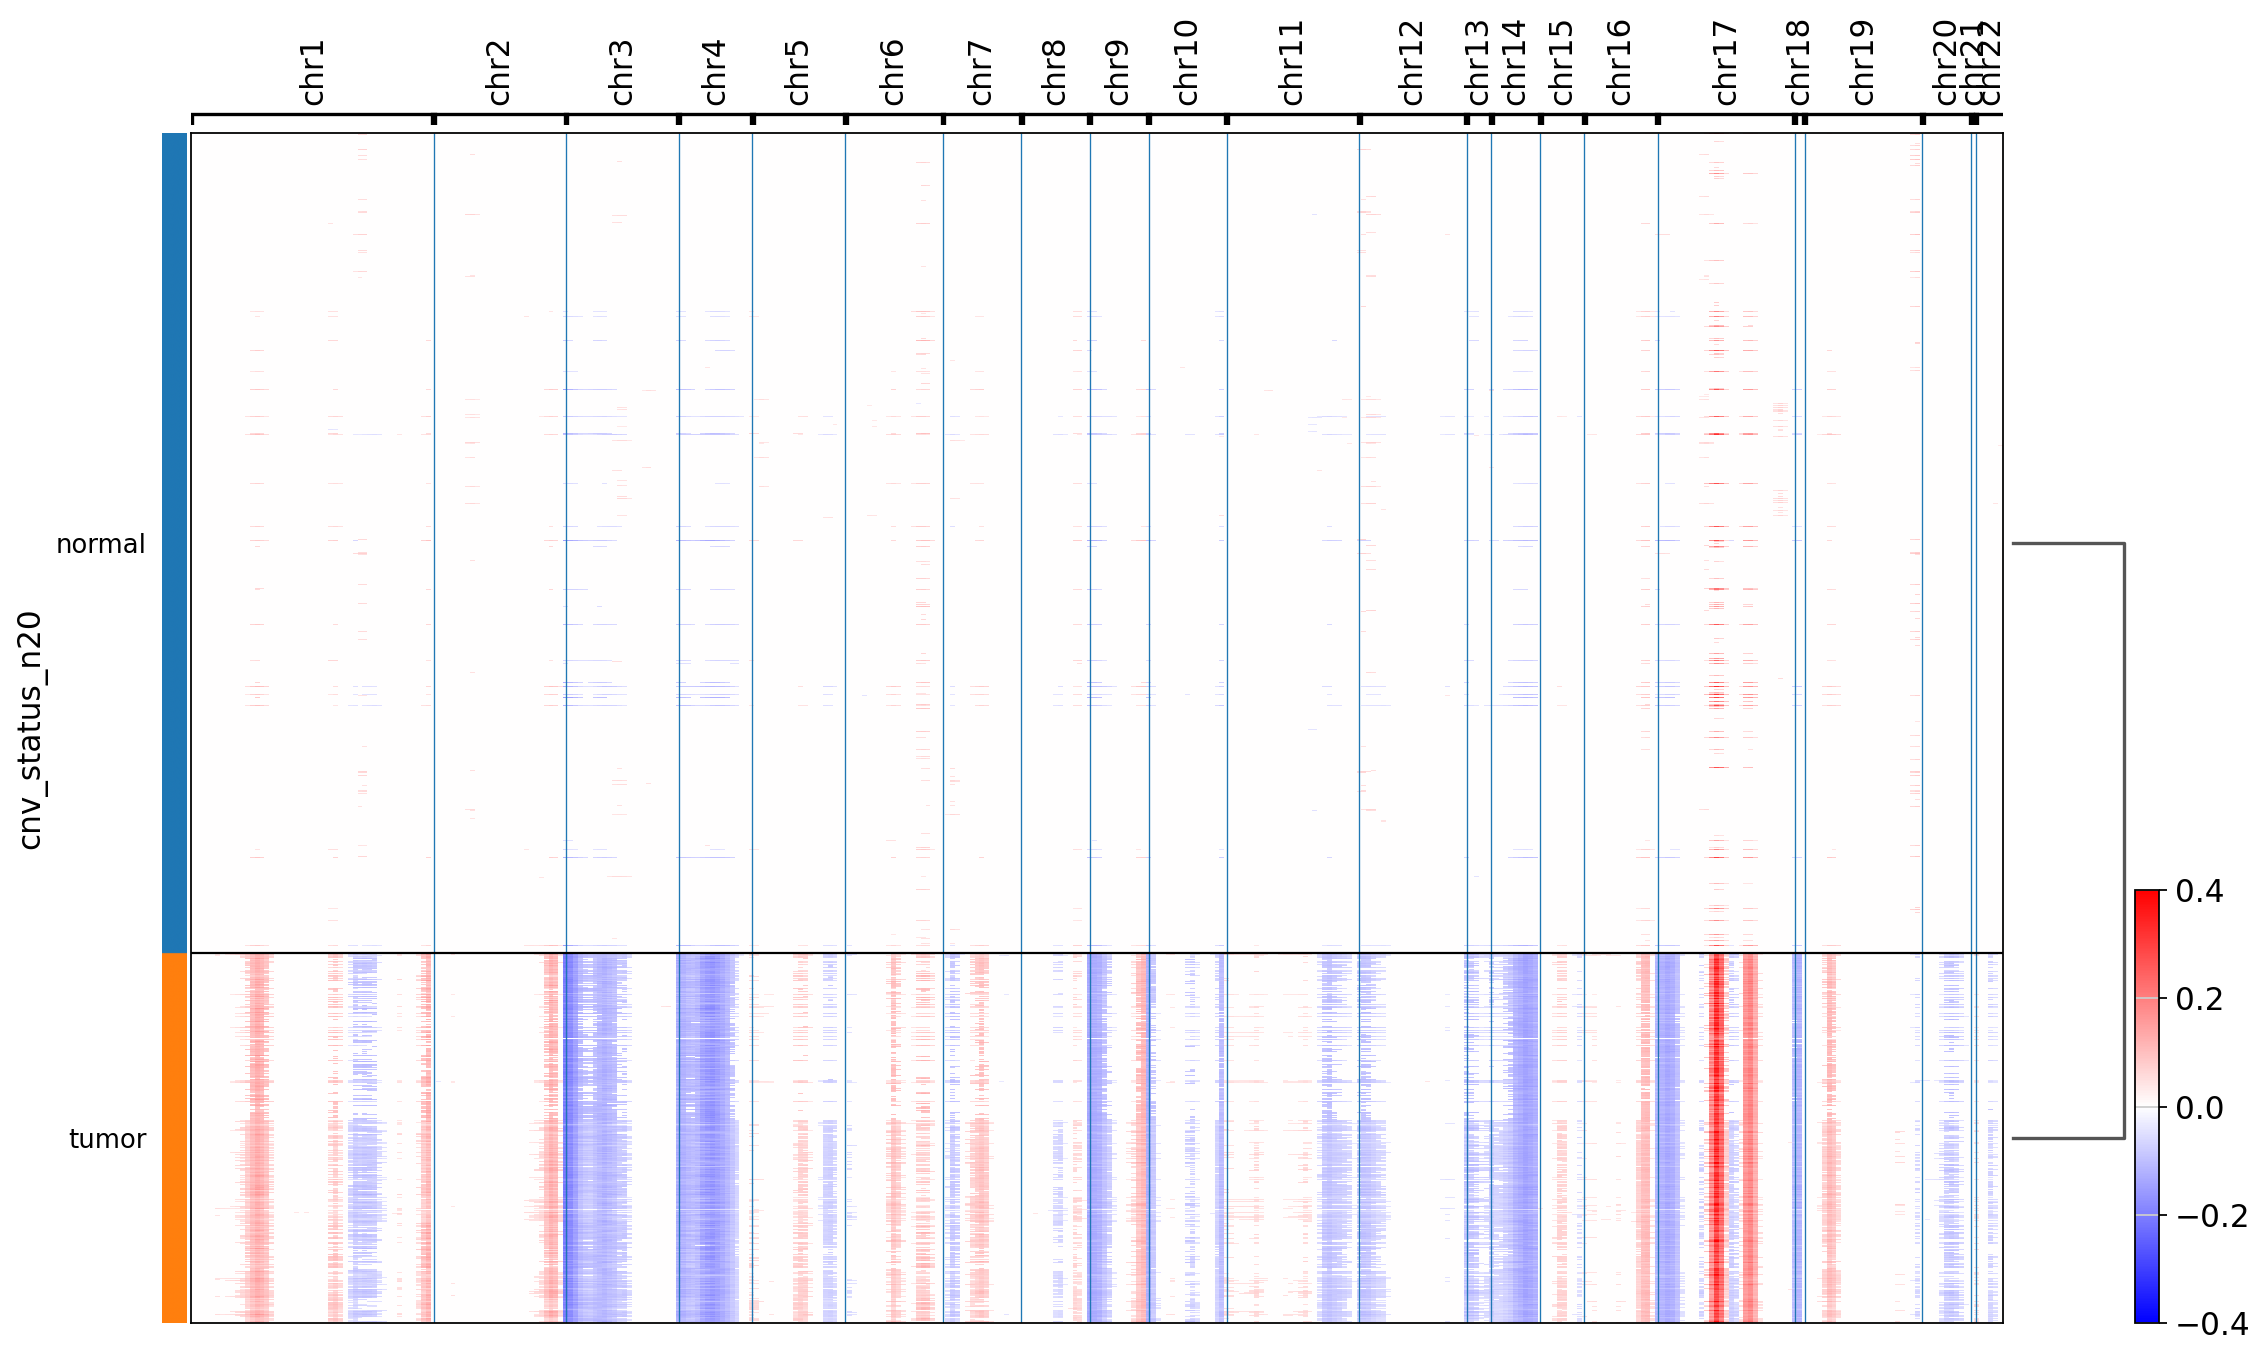

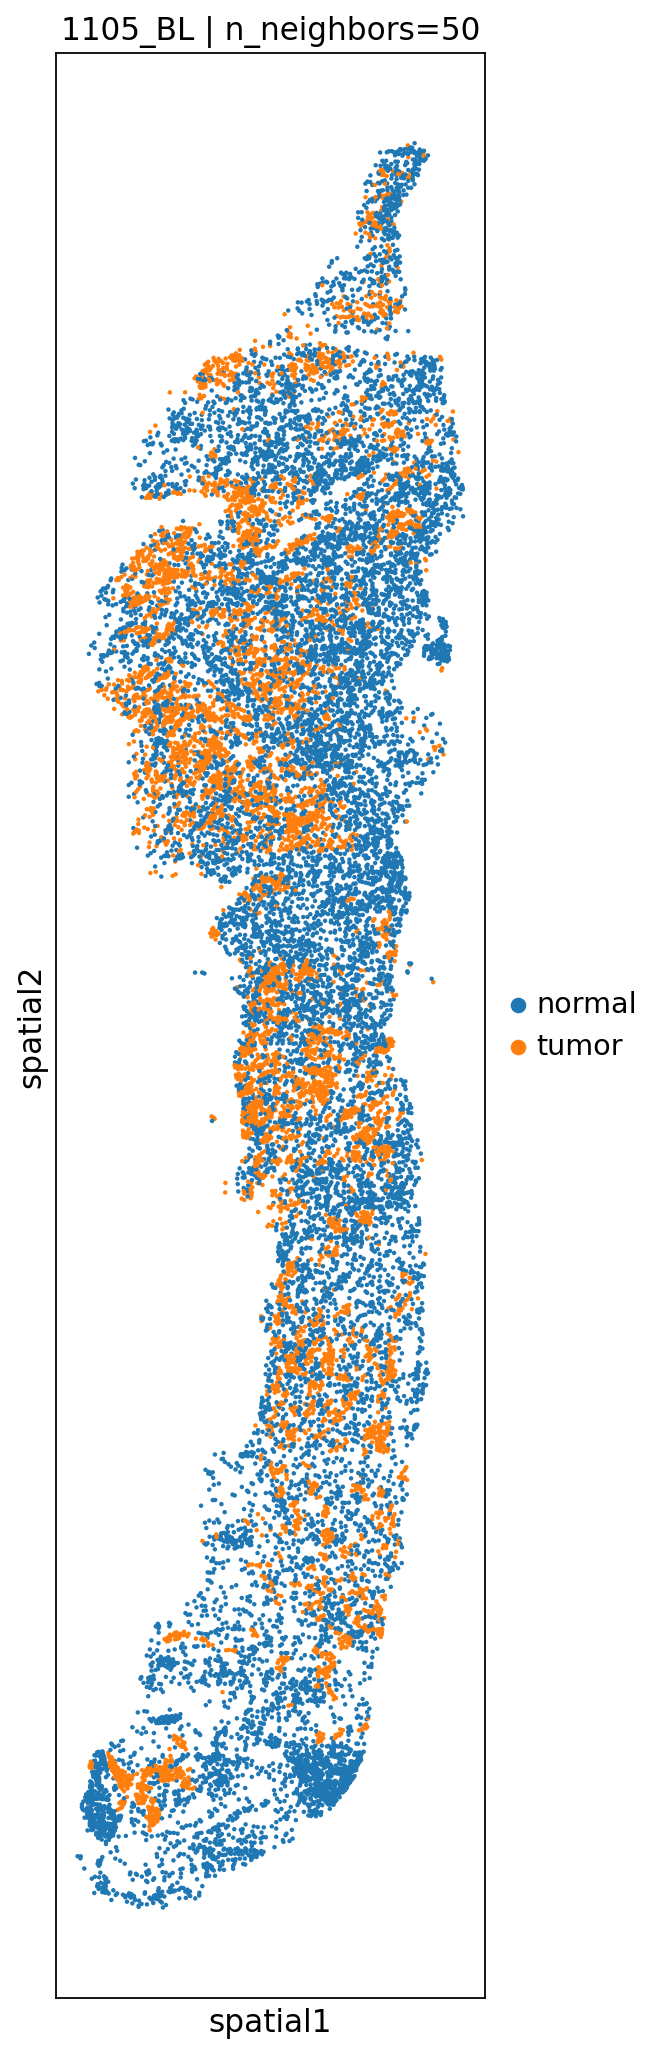

computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_status_n50']`
categories: normal, tumor
var_group_labels: chr1, chr2, chr3, etc.


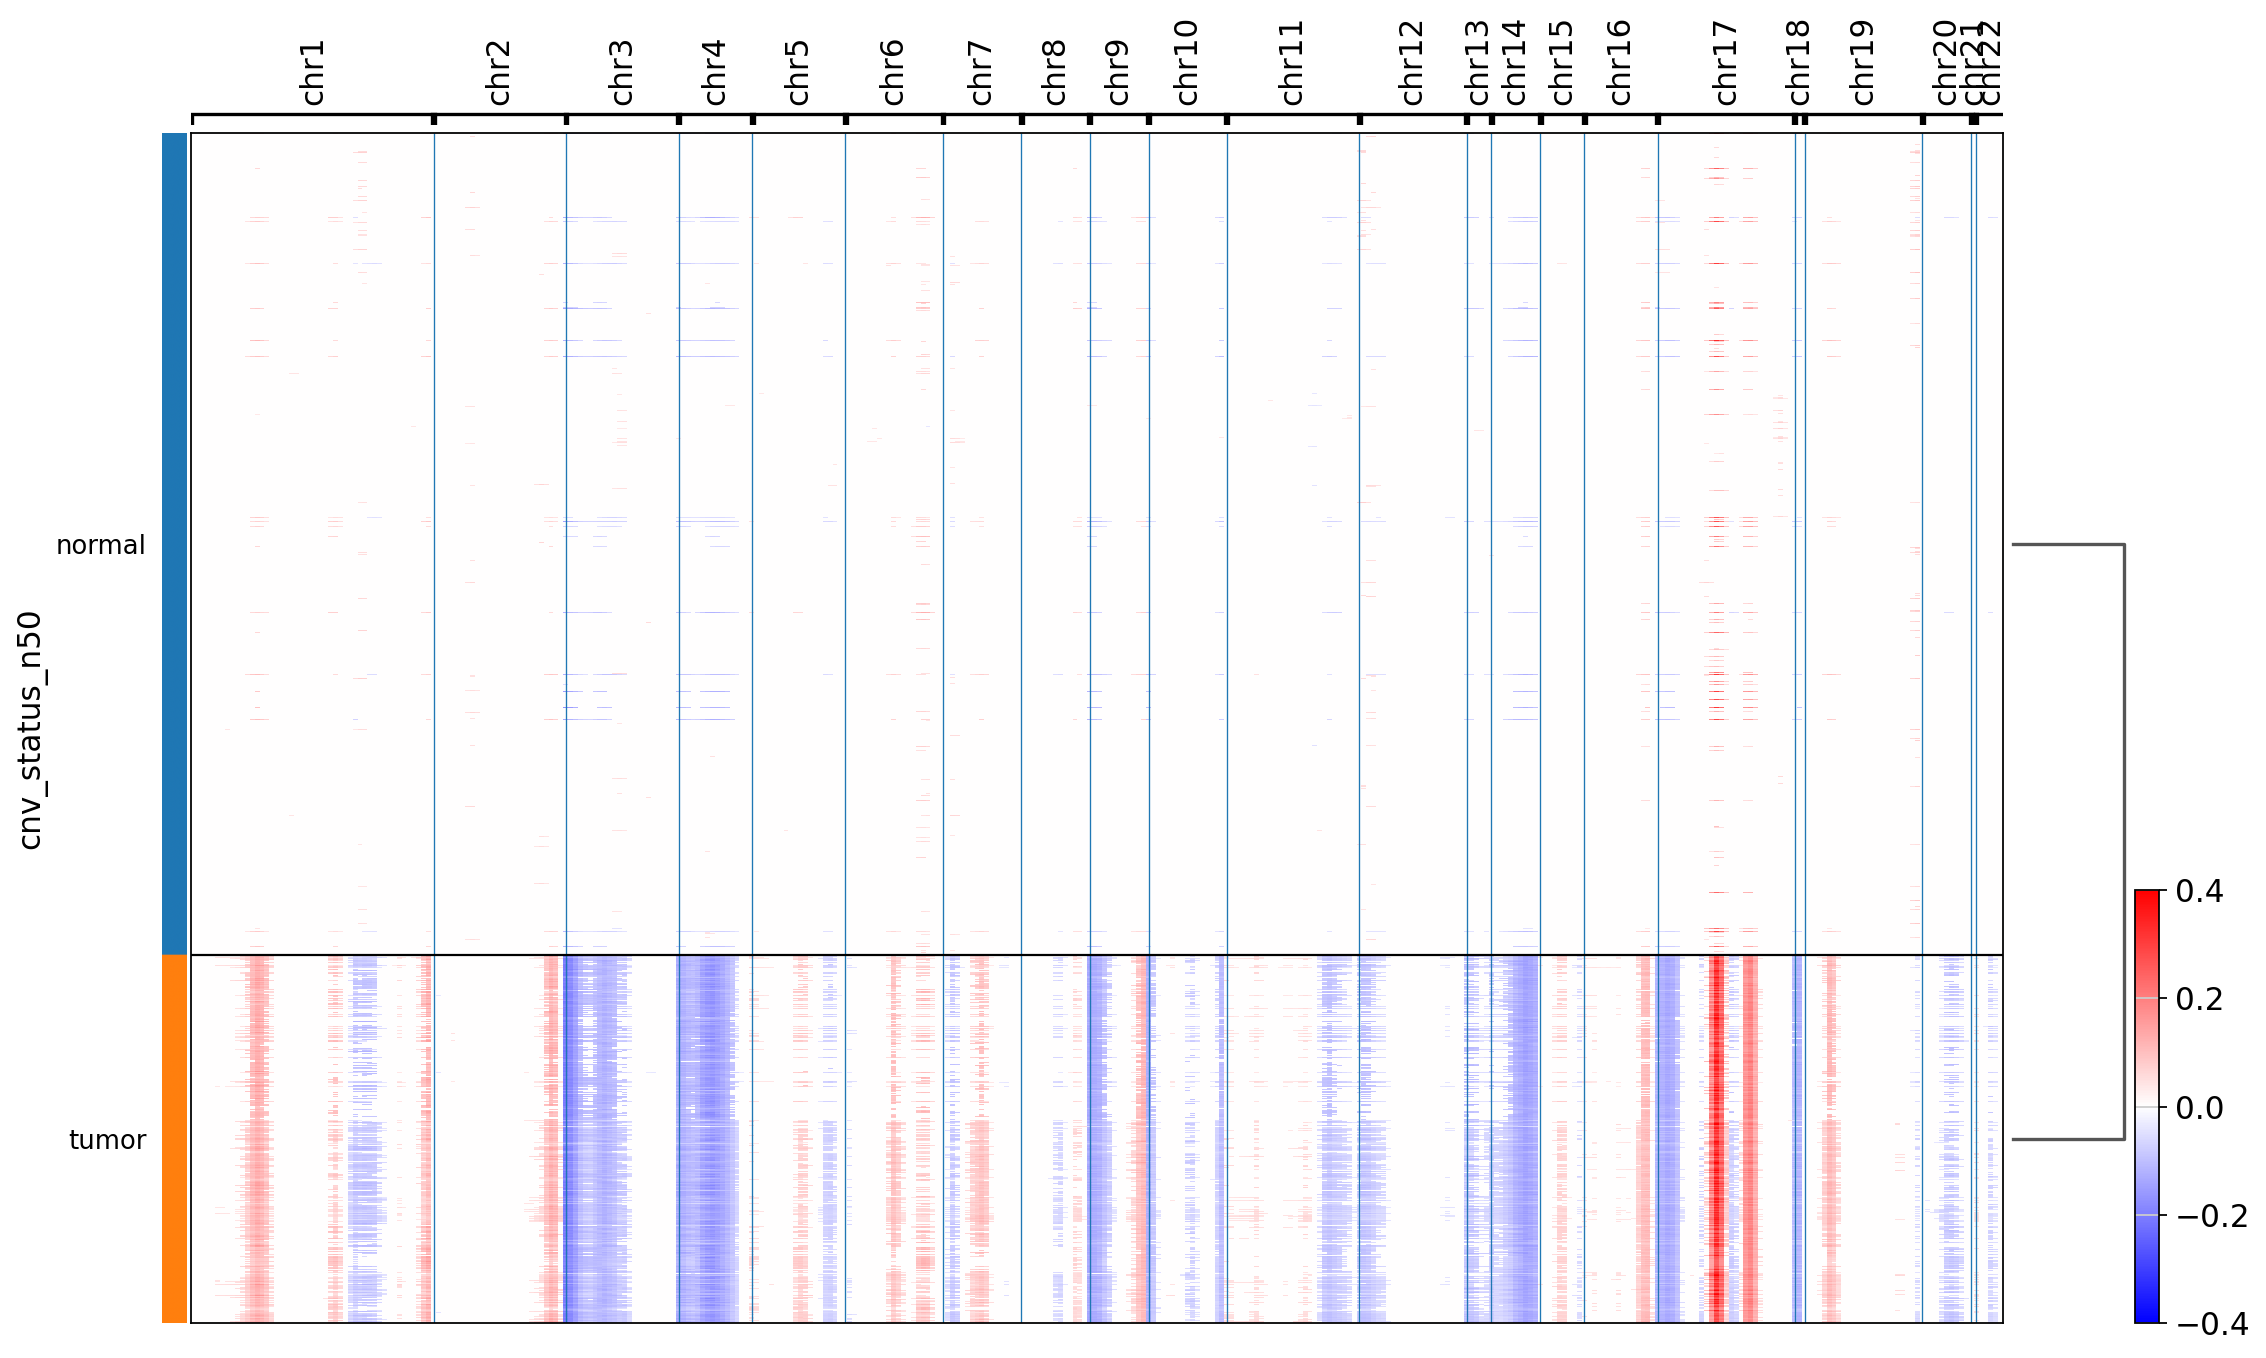

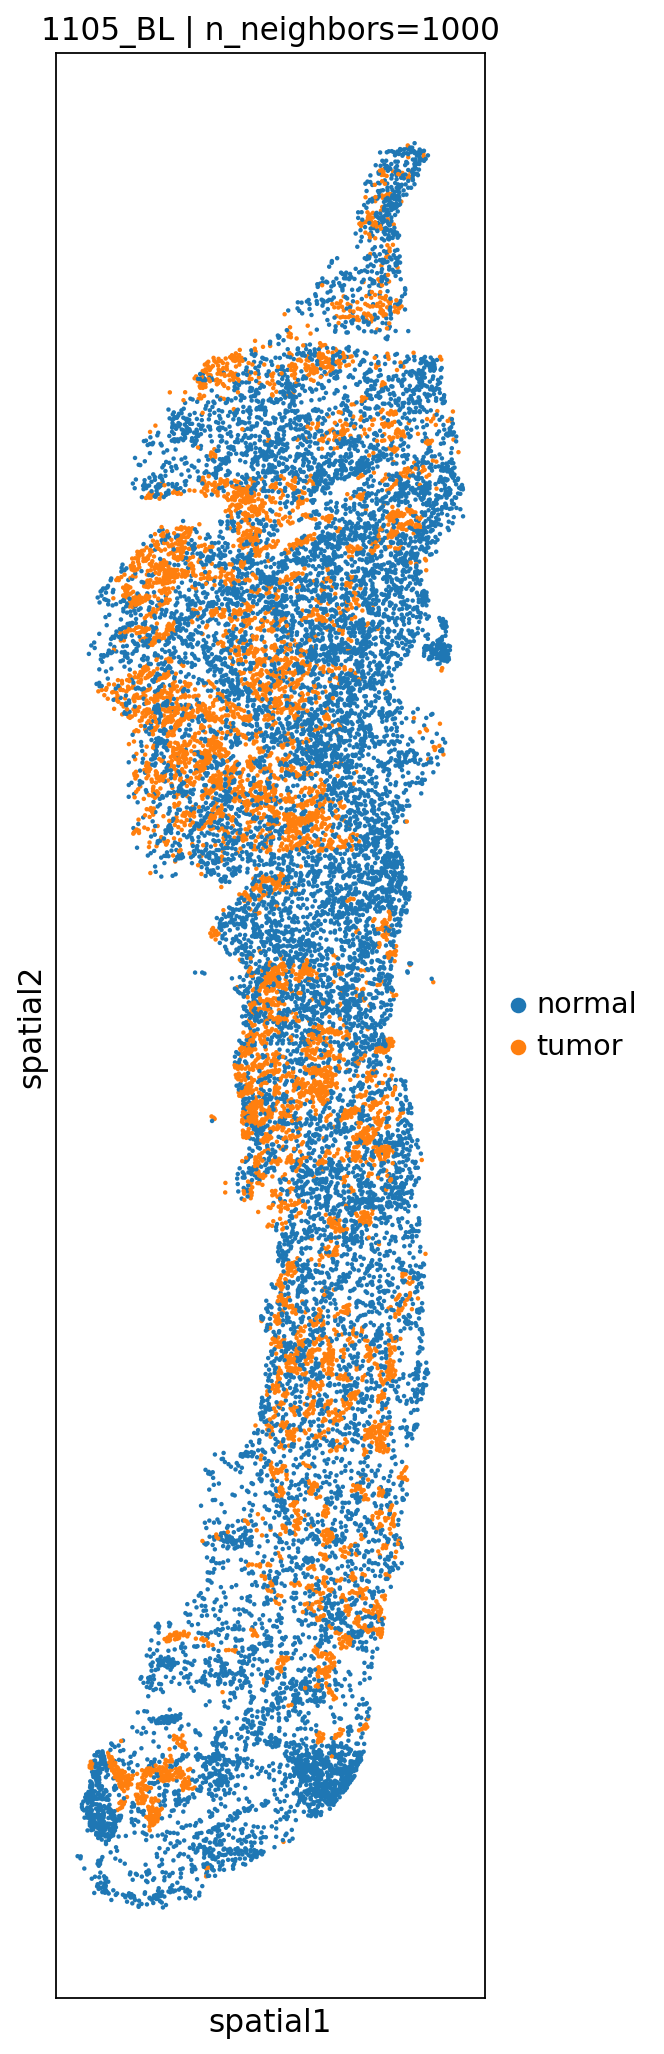

computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_status_n1000']`
categories: normal, tumor
var_group_labels: chr1, chr2, chr3, etc.


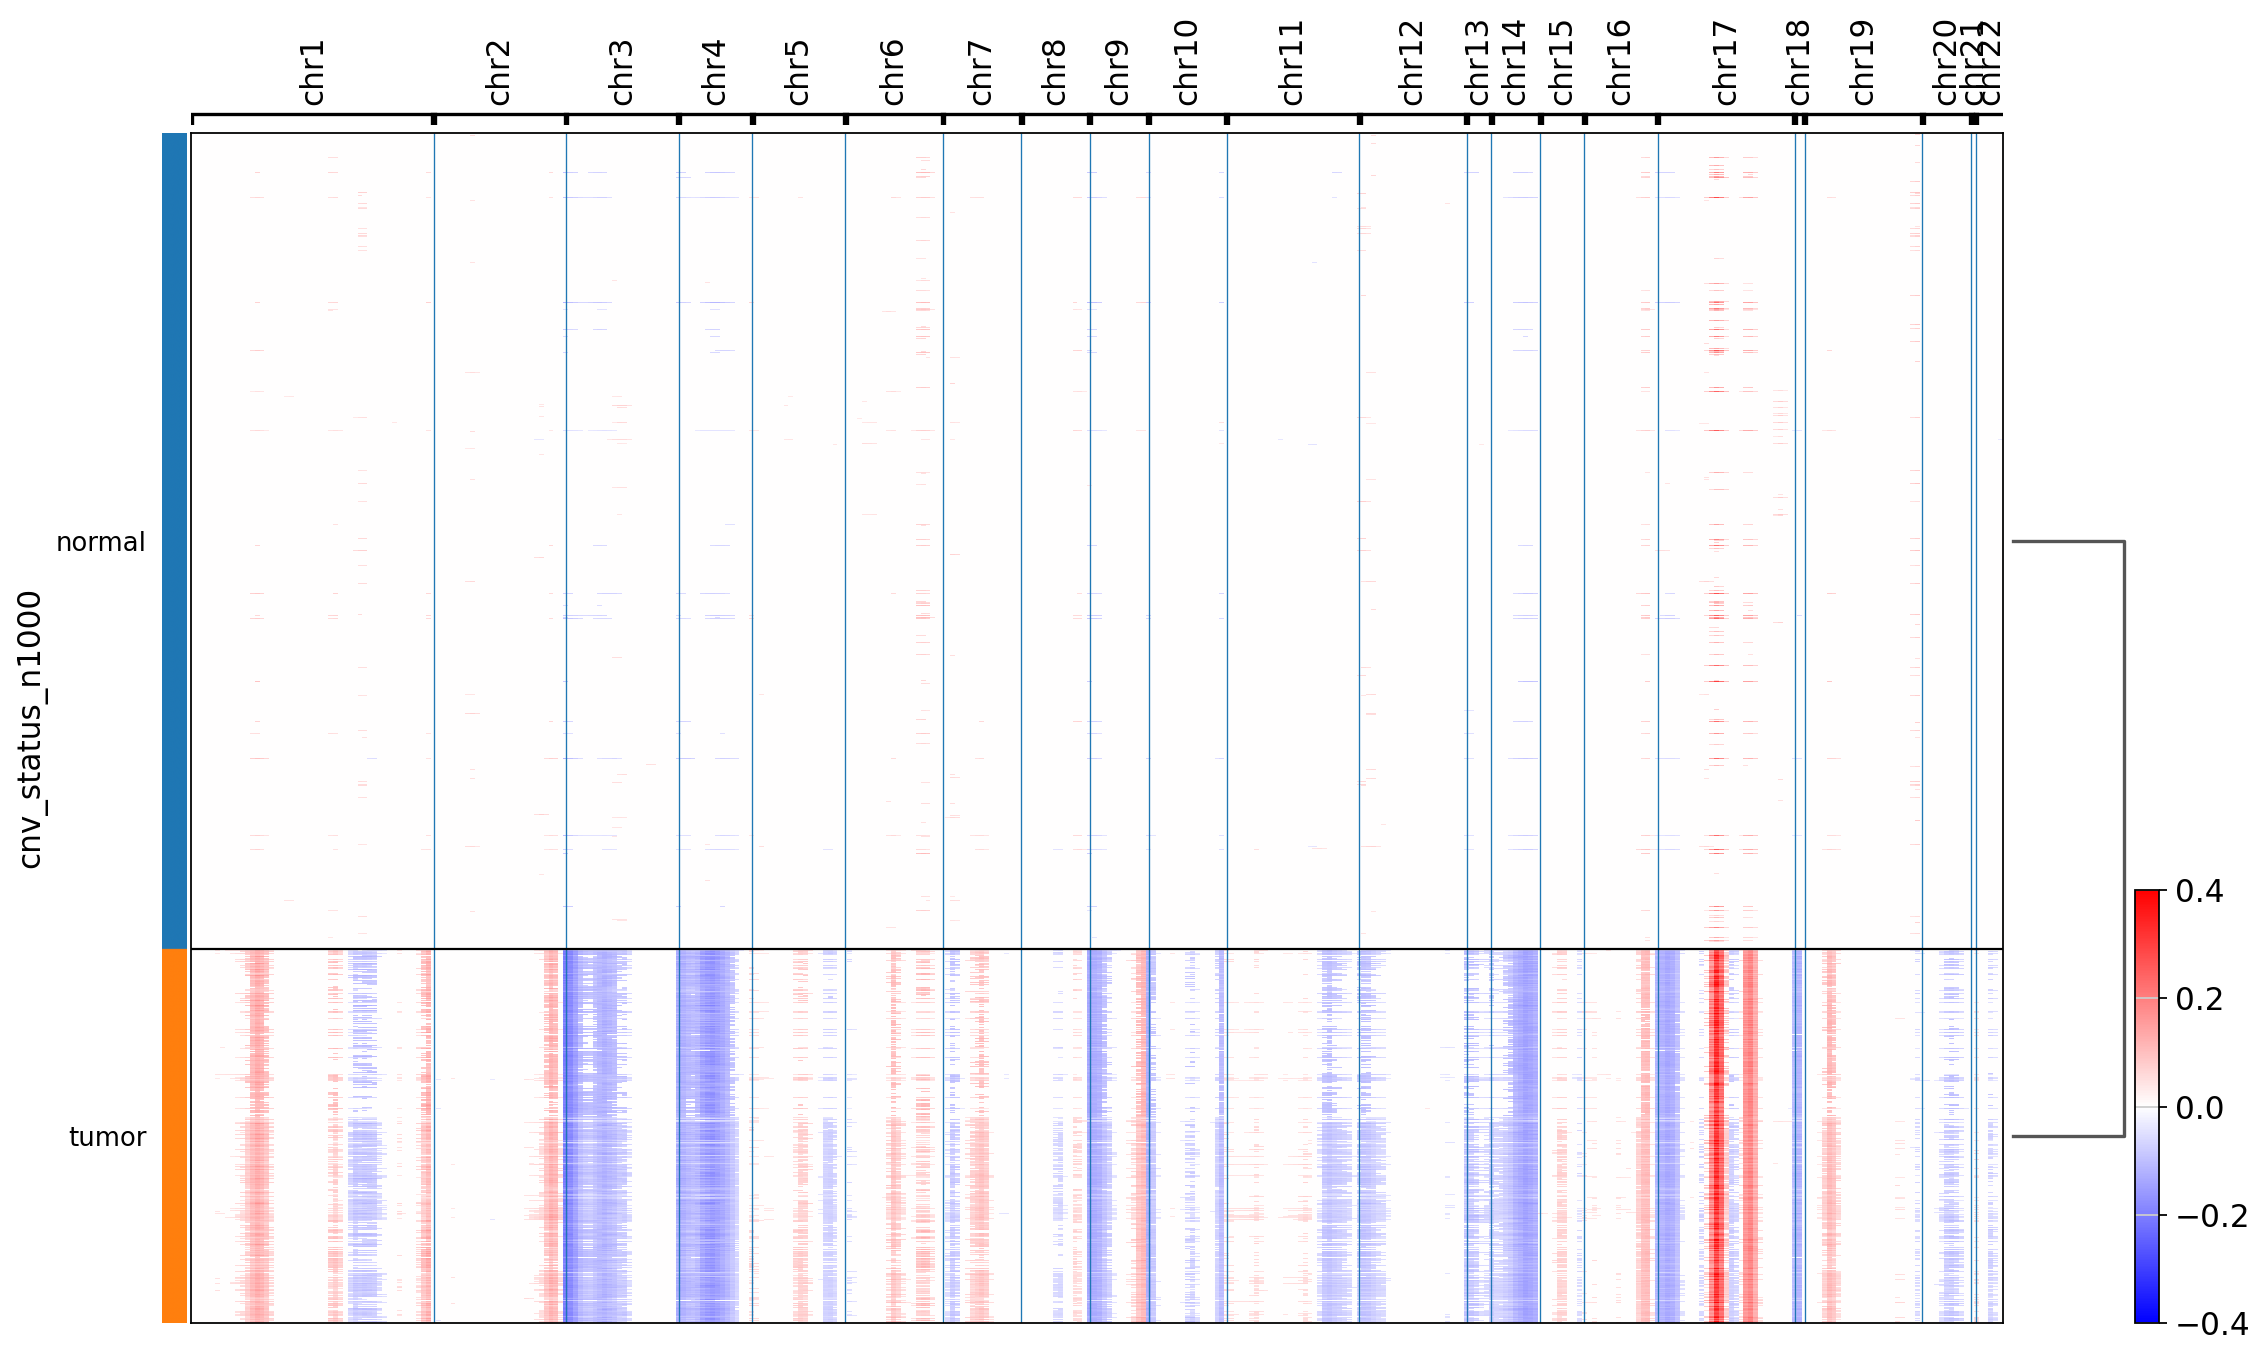

In [26]:
for n in neighbors_list:
    label = f'n{n}'
    """Generate and save the spatial plot"""
    sc.pl.spatial(
        adata,
        color=f'cnv_status_{label}',
        spot_size=15,
        title=f'{sample_name} | n_neighbors={n}',
        save=f'_cnv_leiden_{label}.pdf',
        show=True,
    )
    """Generate and save the heatmap"""
    cnv.pl.chromosome_heatmap(
        adata,
        dendrogram=True,
        groupby=f'cnv_status_{label}',
        vmax=0.4,
        vmin=-0.4,
        save=f'_cnv_status_{label}.pdf',
    )

## Save AnnData with All Neighbor-Count Results


In [32]:
out_path = os.path.join(data_dir, f'{sample_name}_CNV_n_neighbors.h5ad')
adata.write(out_path, compression='gzip')
print('Wrote', out_path)

Wrote /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_n_neighbors/data/1105_BL_CNV_n_neighbors.h5ad
